In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
%cd /home/albin/egna_proj/block_puzzle_rl/

/home/albin/egna_proj/block_puzzle_rl


/home/albin/egna_proj/block_puzzle_rl/.venv/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# your modules
from agent.dqn_agent import DQNAgent
from agent.utils import encode_state
from game.block_puzzle_env import BlockPuzzleEnv
from gymnasium.wrappers import TimeLimit

In [4]:
torch.cuda.is_available()

True

In [5]:
raw_env = BlockPuzzleEnv(width=8, height=8, num_blocks=3)
env = TimeLimit(raw_env, max_episode_steps=1000)
env.env.render(mode='human')

□ □ □ □ □ □ □ □
□ □ □ □ □ □ □ □
□ □ □ □ □ □ □ □
□ □ □ □ □ □ □ □
□ □ □ □ □ □ □ □
□ □ □ □ □ □ □ □
□ □ □ □ □ □ □ □
□ □ □ □ □ □ □ □


In [6]:
obs_dict, next_action_mask = env.reset()
flat_obs = encode_state(obs_dict)
state_dim = flat_obs.shape[0]
action_dim = int(np.prod(env.action_space.nvec))

In [7]:
agent = DQNAgent(
    state_dim=state_dim,
    action_dim=action_dim,
    lr=1e-4,
    gamma=0.99,
    epsilon=1.0,
    epsilon_decay=0.9999,
    epsilon_min=0.05,
)

NUM_EPISODES = 10000
TARGET_UPDATE_FREQ = 1

# Storage
all_rewards = []
all_lengths = []
all_losses = []
global_step = 0


for episode in range(NUM_EPISODES):
    obs_dict, current_action_mask = env.reset() # Renamed for clarity
    state = encode_state(obs_dict)
    ep_reward = 0
    ep_length = 0
    ep_loss = 0
    
    done = False
    
    while not done:
        flat_a = agent.select_action(state, current_action_mask) # Use current_action_mask
        
        a0, a1, a2 = np.unravel_index(flat_a, env.action_space.nvec)
        action = (int(a0), int(a1), int(a2))
        
        # action_mask_for_next_state is the mask associated with next_obs_dict
        ((next_obs_dict, action_mask_for_next_state), reward, terminated, truncated, info) = env.step(action)
        done = terminated or truncated

        # Determine the next_state and its corresponding action_mask for the replay buffer
        next_state_for_buffer = encode_state(next_obs_dict)
        action_mask_for_buffer = action_mask_for_next_state

        agent.replay_buffer.push(
            state=state,
            action=flat_a,
            reward=reward,
            next_state=next_state_for_buffer,
            done=done,
            next_action_mask=action_mask_for_buffer,
        )
        
        loss = agent.train_step()
        if loss is not None:
            ep_loss += loss
        
        state = next_state_for_buffer
        current_action_mask = action_mask_for_next_state # IMPORTANT: Update for the next iteration's select_action
        
        ep_reward += reward
        ep_length += 1
        global_step += 1
        
        if global_step % TARGET_UPDATE_FREQ == 0:
            agent.update_target()
        
        agent.decay_epsilon()
    
    all_rewards.append(ep_reward)
    all_lengths.append(ep_length)
    all_losses.append(ep_loss / ep_length)
    
    if episode % 1 == 0:
        print(f"Episode {episode + 1}/{NUM_EPISODES} | "
              f"Reward: {ep_reward:.2f} | "
              f"Length: {ep_length} | "
              f"Epsilon: {agent.epsilon:.2f}")
    

Episode 1/10000 | Reward: 1.10 | Length: 12 | Epsilon: 1.00
Episode 2/10000 | Reward: -0.20 | Length: 9 | Epsilon: 1.00
Episode 3/10000 | Reward: 0.90 | Length: 10 | Epsilon: 1.00
Episode 4/10000 | Reward: 3.40 | Length: 15 | Epsilon: 1.00
Episode 5/10000 | Reward: 0.90 | Length: 10 | Epsilon: 0.99
Episode 6/10000 | Reward: -0.00 | Length: 11 | Epsilon: 0.99
Episode 7/10000 | Reward: -0.10 | Length: 10 | Epsilon: 0.99
Episode 8/10000 | Reward: 1.00 | Length: 11 | Epsilon: 0.99
Episode 9/10000 | Reward: -0.10 | Length: 10 | Epsilon: 0.99
Episode 10/10000 | Reward: -0.10 | Length: 10 | Epsilon: 0.99
Episode 11/10000 | Reward: 0.10 | Length: 12 | Epsilon: 0.99
Episode 12/10000 | Reward: 10.60 | Length: 27 | Epsilon: 0.99
Episode 13/10000 | Reward: 2.20 | Length: 13 | Epsilon: 0.98
Episode 14/10000 | Reward: 2.20 | Length: 13 | Epsilon: 0.98
Episode 15/10000 | Reward: 1.00 | Length: 11 | Epsilon: 0.98
Episode 16/10000 | Reward: -0.20 | Length: 9 | Epsilon: 0.98
Episode 17/10000 | Reward: -

KeyboardInterrupt: 

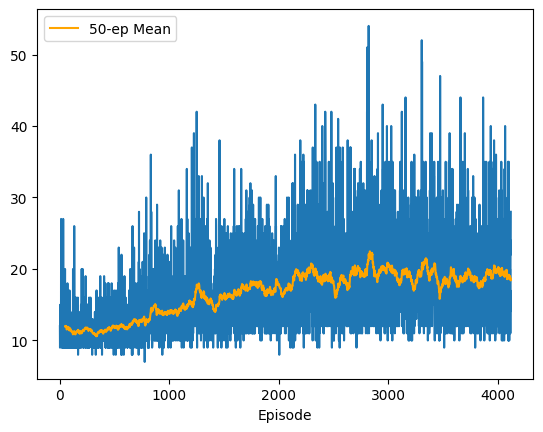

In [8]:
# metric = all_losses
metric = all_lengths

plt.plot(metric, label="")
window = 50
sliding_mean = np.convolve(metric, np.ones(window)/window, mode='valid')
plt.plot(range(window-1, len(metric)), sliding_mean, color='orange', label=f"{window}-ep Mean")
plt.xlabel("Episode")
plt.ylabel("")
plt.legend()
plt.show()

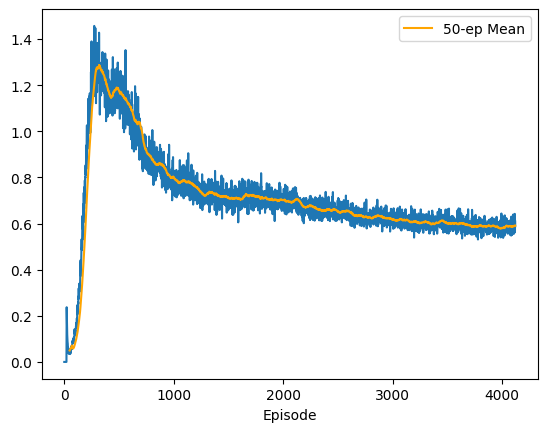

In [9]:
metric = all_losses
# metric = all_lengths

plt.plot(metric, label="")
window = 50
sliding_mean = np.convolve(metric, np.ones(window)/window, mode='valid')
plt.plot(range(window-1, len(metric
                             )), sliding_mean, color='orange', label=f"{window}-ep Mean")
plt.xlabel("Episode")
plt.ylabel("")
plt.legend()
plt.show()

In [17]:
# %% evaluation cell
import time
import numpy as np

# Unwrap the TimeLimit wrapper to call your env’s render()
# Replace `env` here with your actual env variable if different
raw_env = env.env if hasattr(env, 'env') else env

# Ensure render prints to stdout
raw_env.render_mode = 'human'

# Turn off exploration: purely greedy
agent.epsilon = 0.0

# Reset and render initial state
obs_dict, next_action_mask = raw_env.reset()
state = encode_state(obs_dict)
print("Initial grid:")
raw_env.render()

done = False
step = 0

while not done and step < 200:
    # Greedy action
    flat_a = agent.select_action(state, next_action_mask)
    a0, a1, a2 = np.unravel_index(flat_a, raw_env.action_space.nvec)
    action = (int(a0), int(a1), int(a2))
    
    # Step and get reward
    (next_obs, next_action_mask), reward, terminated, truncated, _ = raw_env.step(action)
    state = encode_state(next_obs)

    print(f"\nStep {step+1}: place block {a0} at row {a1}, col {a2} → reward {reward:.1f}")
    raw_env.render()
    
    done = terminated or truncated
    step += 1

if done:
    print(f"\nEpisode finished after {step} steps with total score {raw_env.game.score}")
else:
    print(f"\nStopped after {step} steps (time limit or step cap)")


Initial grid:
□ □ □ □ □ □ □ □
□ □ □ □ □ □ □ □
□ □ □ □ □ □ □ □
□ □ □ □ □ □ □ □
□ □ □ □ □ □ □ □
□ □ □ □ □ □ □ □
□ □ □ □ □ □ □ □
□ □ □ □ □ □ □ □

Step 1: place block 0 at row 3, col 5 → reward 0.1
□ □ □ □ □ □ □ □
□ □ □ □ □ □ □ □
□ □ □ □ □ □ □ □
□ □ □ □ □ ■ ■ □
□ □ □ □ □ □ ■ ■
□ □ □ □ □ □ □ □
□ □ □ □ □ □ □ □
□ □ □ □ □ □ □ □

Step 2: place block 2 at row 6, col 2 → reward 0.1
□ □ □ □ □ □ □ □
□ □ □ □ □ □ □ □
□ □ □ □ □ □ □ □
□ □ □ □ □ ■ ■ □
□ □ □ □ □ □ ■ ■
□ □ □ □ □ □ □ □
□ □ ■ ■ □ □ □ □
□ □ □ ■ ■ □ □ □

Step 3: place block 1 at row 0, col 3 → reward 0.1
□ □ □ ■ ■ □ □ □
□ □ □ □ ■ ■ □ □
□ □ □ □ □ □ □ □
□ □ □ □ □ ■ ■ □
□ □ □ □ □ □ ■ ■
□ □ □ □ □ □ □ □
□ □ ■ ■ □ □ □ □
□ □ □ ■ ■ □ □ □

Step 4: place block 1 at row 3, col 3 → reward 0.1
□ □ □ ■ ■ □ □ □
□ □ □ □ ■ ■ □ □
□ □ □ □ □ □ □ □
□ □ □ ■ ■ ■ ■ □
□ □ □ □ ■ ■ ■ ■
□ □ □ □ □ □ □ □
□ □ ■ ■ □ □ □ □
□ □ □ ■ ■ □ □ □

Step 5: place block 0 at row 4, col 2 → reward 0.1
□ □ □ ■ ■ □ □ □
□ □ □ □ ■ ■ □ □
□ □ □ □ □ □ □ □
□ □ □ ■ ■ ■ ■ □
□ □ ■ ■ ■ ■ ■ ■
□ □ □ 